> 📝 **Planning note (author use -- remove before publishing)**
>
> **Intended contents:** calculate SA, CT, and potential density; a first look at the processed data; T-S diagram / water-mass interpretation.

**To do:** the code is solid and verified -- all narrative bullet placeholders under each header are still empty and need writing. Note that the input file changed (see below), so the T-S diagram will look different from what you had.

<img src="../../data/images/hiaoos_learning_moored.png" width="300" align="right">

# Calculating derived parameters and hydrographic analysis

- Calculating Absolute Salinity, Conservative Temperature, and density
    - EXPLAIN TEOS10 and gsw! (reference them!)
- A first look at the processed data
- Hydrographic analysis: the data in temperature-salinity space

In [1]:
from kval.data import moored
import matplotlib.pyplot as plt
%matplotlib widget

> ✏️ **Review note** — this loaded `..._from_raw.nc`, i.e. the file from notebook 2, skipping everything notebooks 4 and 5 did. Repointed to `..._edited.nc`. This is not cosmetic: the raw file still contains the pre-deployment deck record, which shows up in T-S space as a stray cloud of warm, fresh (or NaN-salinity) points. Also switched `xr.open_dataset` to `moored.load_nc` for consistency with the rest of the series.

In [2]:
# Specify where we want to load the file from
src_path = '../../data/moored_CTD_test_data/intermediate_data/'

# Specify a file name
src_name = 'AT800_21_22_CONCERTO_60595_99m_edited.nc'

ds = moored.load_nc(src_path + src_name)

### Calculate SA, CT, and density

- 
- 
- 

In [3]:
ds = moored.calculate_SA_CT(ds)

In [4]:
ds = moored.calculate_sig0(ds)

### A first look at the data

- 

In [5]:
ds #(inspect)

<xarray.Dataset> Size: 2MB
Dimensions:    (TIME: 23648)
Coordinates:
  * TIME       (TIME) float64 189kB 1.894e+04 1.894e+04 ... 1.911e+04 1.911e+04
    LATITUDE   float32 4B ...
    LONGITUDE  float32 4B ...
Data variables:
    CNDC       (TIME) float64 189kB ...
    TEMP       (TIME) float64 189kB ...
    PRES       (TIME) float64 189kB ...
    DEPTH      (TIME) float64 189kB ...
    PSAL       (TIME) float64 189kB ...
    SVEL       (TIME) float64 189kB ...
    SPCNDC     (TIME) float64 189kB ...
    SA         (TIME) float64 189kB 35.06 35.04 35.05 ... 34.91 34.91 34.91
    CT         (TIME) float64 189kB 3.867 3.77 3.871 4.078 ... 1.262 1.232 1.324
    SIG0       (TIME) float64 189kB 27.71 27.71 27.71 ... 27.82 27.82 27.82
Attributes:
    history:                   2021-11-08 - 2022-04-24: Data collection.\n202...
    date_created:              2026-09-23T12:13:34Z
    instrument_model:          RBRconcerto
    instrument_serial_number:  60595
    source_file:               AT800_21_22_CONCERTO_60595_99m.rsk
    time_coverage_resolution:  P0000-00-00T00:10:00
    sampling_details:          One average of 15 samples collected at 2 sec i...

In [6]:
moored.plot(ds)

### Hydrographic analysis: the data in temperature-salinity space

- 
- 
- 

In [7]:
moored.tsplot_pick(ds)

### Compare

In [8]:
ds_at800_100m = ds 

In [9]:
ds_at200_50m = moored.load_moored('../../data/moored_CTD_test_data/intermediate_data/AT200_21_22_SBE37_20773_49m_edited.nc')
ds_at200_50m = moored.calculate_SA_CT(ds_at200_50m)

In [10]:
moored.tsplot_pick(ds_at200_50m)

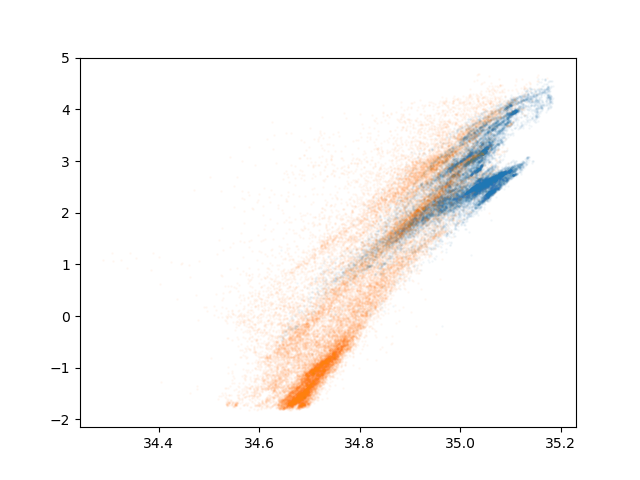

In [13]:
fig, ax = plt.subplots()
scatter_kws = {'alpha':0.03, 's':1}
ax.scatter(ds_at800_100m.SA, ds_at800_100m.CT, label = 'AT800 100 m', **scatter_kws)
ax.scatter(ds_at200_50m.SA, ds_at200_50m.CT, label = 'AT200 100 m', **scatter_kws)